# 13 — TensorFlow & Keras: Same Concepts, Second Framework

Modules 10-12 built tensors, autograd, training loops, and regularization
entirely in PyTorch. None of that was PyTorch-specific *conceptually* —
every deep learning framework needs a tensor type, a way to compute
gradients, a way to define layers, and a training loop. This notebook
proves that by rebuilding the same handful of examples in
**TensorFlow/Keras**, side by side with what you already know, rather than
teaching the concepts a second time.

**Covered:**
1. Tensors & `GradientTape` (TensorFlow's autograd) vs. PyTorch's tensors/`.backward()`
2. The same MLP via `tf.keras.Sequential` and via subclassing `tf.keras.Model`
3. Keras's `.compile()`/`.fit()` vs. PyTorch's explicit training loop — same data, same architecture, same result
4. A side-by-side syntax reference
5. Which framework, when

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"    # silence TensorFlow's verbose startup logging
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"   # ditto -- these must be set before `import tensorflow`

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

sns.set_theme(style="whitegrid")
tf.random.set_seed(13)
rng = np.random.default_rng(13)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPUs available: {tf.config.list_physical_devices('GPU')}")  # expect [] in this CPU-only environment

TensorFlow version: 2.21.0
GPUs available: []


## 1. Tensors & `GradientTape`

**Theory.** `tf.Tensor` plays the same role as `torch.Tensor`. The big
mechanical difference is *how* autograd is triggered:

- **PyTorch** — any tensor with `requires_grad=True` is tracked automatically, for as long as it exists.
- **TensorFlow** — you explicitly open a `tf.GradientTape()` context; only operations recorded *inside* that block get differentiated, and the tape is normally used once then discarded.

Same `y = x^2` example from `10_deep_learning_foundations`, this time with a tape.

In [2]:
x = tf.Variable(3.0)  # tf.Variable, not tf.constant, since we need something mutable/trainable

with tf.GradientTape() as tape:
    y = x ** 2

dy_dx = tape.gradient(y, x)
print(f"x = {x.numpy()}")
print(f"y = x^2 = {y.numpy()}")
print(f"GradientTape's dy/dx = {dy_dx.numpy()}")
print(f"hand-computed 2x = {2 * x.numpy()}")

x = 3.0
y = x^2 = 9.0
GradientTape's dy/dx = 6.0
hand-computed 2x = 6.0


In [3]:
# The two-variable example from Module 10, replicated with a tape
a = tf.Variable(2.0)
b = tf.Variable(5.0)

with tf.GradientTape() as tape:
    c = a * b
    d = c + a ** 2

grad_a, grad_b = tape.gradient(d, [a, b])
print(f"d = a*b + a^2 = {d.numpy()}")
print(f"tape dd/da = {grad_a.numpy()}  (hand-computed: b + 2a = {b.numpy() + 2*a.numpy()})")
print(f"tape dd/db = {grad_b.numpy()}  (hand-computed: a = {a.numpy()})")

d = a*b + a^2 = 14.0
tape dd/da = 9.0  (hand-computed: b + 2a = 9.0)
tape dd/db = 2.0  (hand-computed: a = 2.0)


Identical results to Module 10's PyTorch version — the mechanism (build a
graph of operations, walk it backward) is the same; only the API for
"start tracking now" differs (implicit via `requires_grad` vs. explicit via
`GradientTape()`).

## 2. The Same MLP, Two Ways

**Theory.** Keras offers two ways to define a model, mirroring PyTorch's
`nn.Sequential` vs. subclassing `nn.Module` from Module 11:

- **`tf.keras.Sequential`** — a straight stack of layers, for simple architectures.
- **Subclassing `tf.keras.Model`** — write `__init__` (layers) and `call` (forward pass) explicitly, needed once architectures stop being a simple stack (branches, skip connections — relevant again in Module 15's CNNs).

In [4]:
from tensorflow.keras import layers

# Equivalent to Module 11's MLP(in_features=64, hidden_sizes=[32, 16], n_classes=10) via nn.Sequential
sequential_model = tf.keras.Sequential([
    layers.Input(shape=(64,)),
    layers.Dense(32, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(10),  # logits, same convention as the PyTorch version
])
sequential_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,778 (10.85 KB)

 Trainable params: 2,778 (10.85 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# The same network via subclassing -- directly comparable to Module 11's `class MLP(nn.Module)`
class MLP(tf.keras.Model):
    def __init__(self, hidden_sizes, n_classes):
        super().__init__()
        self.hidden_layers = [layers.Dense(h, activation="relu") for h in hidden_sizes]
        self.output_layer = layers.Dense(n_classes)

    def call(self, x):
        for layer in self.hidden_layers:
            x = layer(x)
        return self.output_layer(x)

subclassed_model = MLP(hidden_sizes=[32, 16], n_classes=10)
subclassed_model(tf.zeros((1, 64)))  # a real forward pass builds every sublayer (safer than calling .build() directly)
subclassed_model.summary()

Model: "mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (1, 32)                │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (1, 16)                │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (1, 10)                │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,778 (10.85 KB)

 Trainable params: 2,778 (10.85 KB)

 Non-trainable params: 0 (0.00 B)

Compare this cell-for-cell against Module 11's `class MLP(nn.Module)`:
PyTorch's `__init__`/`forward` becomes Keras's `__init__`/`call`, and
`nn.Linear` becomes `layers.Dense` — the same idea, different names.

## 3. `.compile()`/`.fit()` vs. the Explicit Training Loop

**Theory.** This is the biggest *practical* difference between the
frameworks. Keras's `.compile()` + `.fit()` hides the batch loop, the
`zero_grad()`/`.backward()`/`optimizer.step()` sequence, and the
train/eval-mode switching that Module 11 wrote out by hand — trading
visibility for far less boilerplate on standard training setups.

We train on the exact same `load_digits` split Module 11 used, so results
are directly comparable.

In [6]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

digits = load_digits()
X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
    digits.data, digits.target, test_size=0.2, random_state=11, stratify=digits.target
)
scaler = StandardScaler().fit(X_train_np)
X_train = scaler.transform(X_train_np).astype("float32")
X_test = scaler.transform(X_test_np).astype("float32")
y_train, y_test = y_train_np, y_test_np

In [7]:
tf.random.set_seed(11)
keras_model = tf.keras.Sequential([
    layers.Input(shape=(64,)),
    layers.Dense(32, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(10),
])

keras_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),  # from_logits=True since we skip a final softmax, same as PyTorch's CrossEntropyLoss
    metrics=["accuracy"],
)

history = keras_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=30, batch_size=32, verbose=0,
)

test_loss, test_acc = keras_model.evaluate(X_test, y_test, verbose=0)
print(f"Keras final test accuracy: {test_acc:.3f}")
print(f"(Module 11's PyTorch MLP, same data/architecture, reached ~0.97 test accuracy)")

Keras final test accuracy: 0.969
(Module 11's PyTorch MLP, same data/architecture, reached ~0.97 test accuracy)


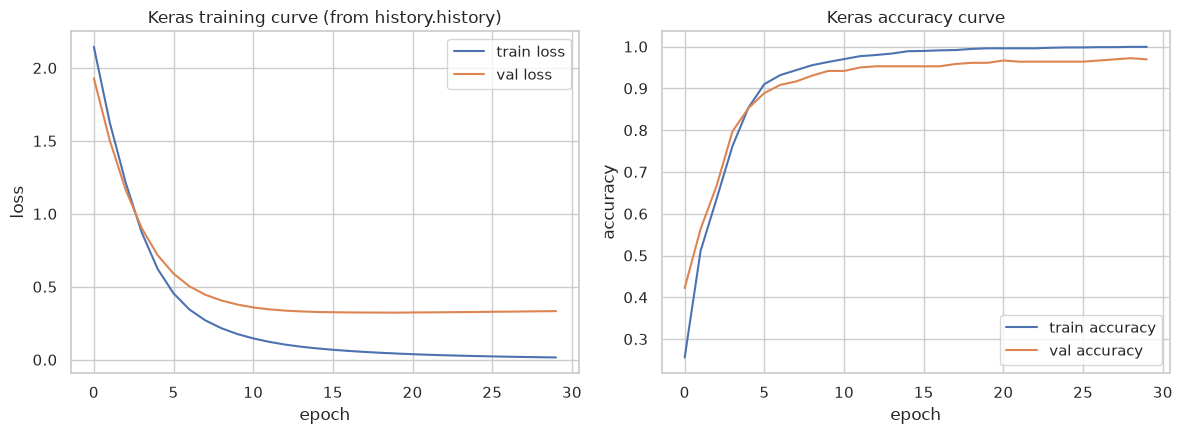

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(history.history["loss"], label="train loss")
axes[0].plot(history.history["val_loss"], label="val loss")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss"); axes[0].legend()
axes[0].set_title("Keras training curve (from history.history)")

axes[1].plot(history.history["accuracy"], label="train accuracy")
axes[1].plot(history.history["val_accuracy"], label="val accuracy")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("accuracy"); axes[1].legend()
axes[1].set_title("Keras accuracy curve")
plt.tight_layout()
plt.show()

`history.history` is Keras's equivalent of the `train_losses`/`test_losses`
lists Module 11 built by hand — `.fit()` tracks them for you automatically
as a side effect of training, rather than requiring an explicit
`model.eval()` block inside the loop.

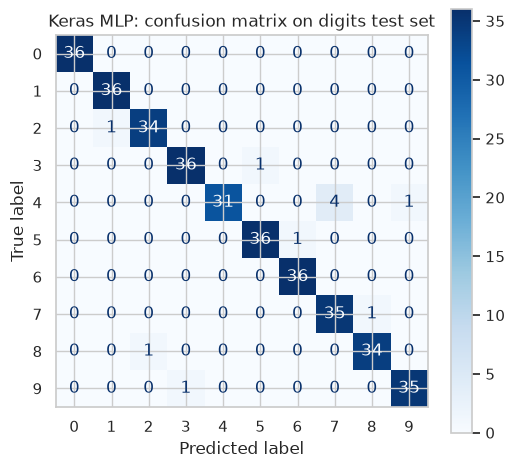

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = keras_model.predict(X_test, verbose=0).argmax(axis=1)

fig, ax = plt.subplots(figsize=(6, 5.5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues", ax=ax)
ax.set_title("Keras MLP: confusion matrix on digits test set")
plt.show()

## 4. Side-by-Side Syntax Reference

| Concept | PyTorch | TensorFlow/Keras |
|---|---|---|
| Tensor | `torch.tensor(...)` | `tf.constant(...)` / `tf.Variable(...)` |
| Track gradients | `requires_grad=True` (implicit, ongoing) | `tf.GradientTape()` (explicit, per-computation) |
| Compute gradients | `loss.backward()`, then read `.grad` | `tape.gradient(loss, vars)` |
| Simple stacked model | `nn.Sequential(...)` | `tf.keras.Sequential([...])` |
| Custom model | subclass `nn.Module`, define `forward` | subclass `tf.keras.Model`, define `call` |
| Linear/Dense layer | `nn.Linear(in, out)` | `layers.Dense(out)` |
| Cross-entropy loss | `nn.CrossEntropyLoss()` (expects logits) | `SparseCategoricalCrossentropy(from_logits=True)` |
| Optimizer | `torch.optim.Adam(model.parameters())` | `tf.keras.optimizers.Adam()` |
| Training loop | written by hand (Module 11) | `model.fit(X, y, epochs=...)` |
| Model summary | `torchinfo.summary(model, ...)` | `model.summary()` |

## 5. Which Framework, When?

- **PyTorch** — favored in research and whenever you need to see or modify
  *what's happening between the layers*: custom training loops, novel
  architectures, non-standard losses. Modules 14-19 (CNNs, RNNs,
  Transformers) continue in PyTorch for exactly this reason — the internals
  need to stay visible.
- **Keras** — favored for fast iteration on standard architectures where
  `.compile()`/`.fit()` covers what you need; also a gentler starting point
  for a first deep learning framework, given how much boilerplate it
  removes.

In practice, both compute the same gradients the same way underneath —
picking one is about *how much of the machinery you want to see*, not a
difference in what's mathematically possible.

## Exercises

1. Change the Keras optimizer from `Adam` to `SGD(learning_rate=0.01, momentum=0.9)` and compare the resulting training curve against Module 11's SGD+Momentum comparison — does the shape look similar?
2. Add a `Dropout(0.5)` layer between the two `Dense` hidden layers in the Sequential model — does `model.summary()` show it having any parameters? Why not, given what Module 12 said about how Dropout works?
3. Rewrite the two-variable `GradientTape` example in section 1 for `d = a**2 * b + b**3` and verify `tape.gradient` against a hand-derived partial derivative.

## Key Takeaways

- TensorFlow's `GradientTape` and PyTorch's `requires_grad`/`.backward()` compute the exact same kind of gradients — the only difference is whether tracking is scoped explicitly (tape) or implicitly (flag).
- `tf.keras.Sequential`/subclassed `tf.keras.Model` map directly onto PyTorch's `nn.Sequential`/subclassed `nn.Module` — same architecture, different class names.
- Keras's `.compile()`/`.fit()` trades explicit control (what Module 11's hand-written loop gave us) for much less code on standard training setups.
- Neither framework is "more correct" — they're two interfaces to the same underlying autograd + gradient descent mechanism from Module 10.